In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('clean_comments.csv')
df.dropna(inplace=True)
df.head()

,Unnamed: 0,clean_comment,category
0,0,family mormon have never tried explain them th...,2.0
1,1,buddhism has very much lot compatible with chr...,2.0
2,2,seriously don say thing first all they won get...,0.0
3,3,what you have learned yours and only yours wha...,1.0
4,4,for your own benefit you may want read living ...,2.0


In [10]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [11]:
def preprocess_comment(comment):
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [12]:
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

df.head()

,Unnamed: 0,clean_comment,category
0,0,family mormon never tried explain still stare ...,2.0
1,1,buddhism much lot compatible christianity espe...,2.0
2,2,seriously say thing first get complex explain ...,0.0
3,3,learned want teach different focus goal not wr...,1.0
4,4,benefit may want read living buddha living chr...,2.0


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#Creating a bag of words
vectorizer = CountVectorizer(max_features=1000)

In [30]:
X = vectorizer.fit_transform(df['clean_comment']).toarray().astype('float32')
y = df['category']

In [31]:
print(X.shape)
y.shape

(50050, 1000)


(50050,)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
n_estimators = 200
max_depth = 15

model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42)

Text(0.5, 1.0, 'Confusion Matrix')

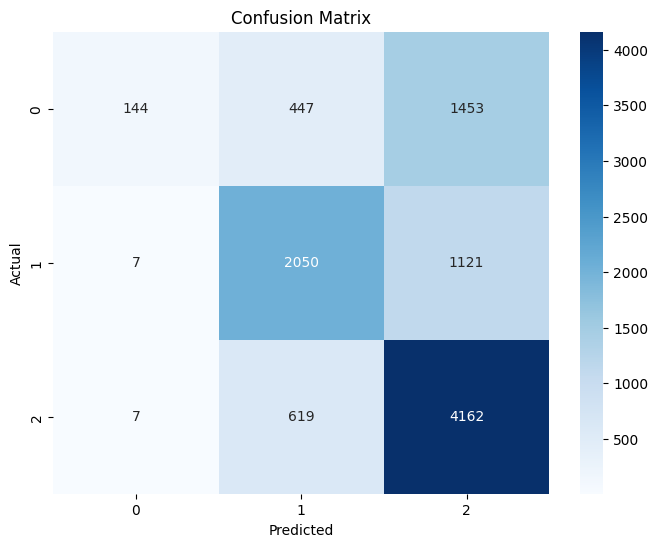

In [34]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, output_dict=True)

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.05      0.10      2044
         1.0       0.75      0.49      0.60      3178
         2.0       0.57      0.93      0.71      4788

    accuracy                           0.61     10010
   macro avg       0.75      0.49      0.47     10010
weighted avg       0.70      0.61      0.55     10010



In [21]:
df.to_csv('clean_comments.csv')